# Akomolafe Nathaniel Iyanuoluwa Data Science Email Spam Detection with Machine Learning

**Objective:** Build a binary text classifier distinguishing spam from legitimate (ham) messages.

**Dataset:** SMS Spam Collection Dataset (5,572 labelled messages).

## Loading the Data

In [58]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

Emai_spam = pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 4\spam.csv", encoding='latin-1')
Emai_spam = Emai_spam[['v1', 'v2']]
Emai_spam.columns = ['label', 'text']
Emai_spam.head()


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [59]:
Emai_spam.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


## Class Distribution

label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
 label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_11600\321474297.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Emai_spam, x='label', palette='Set2')


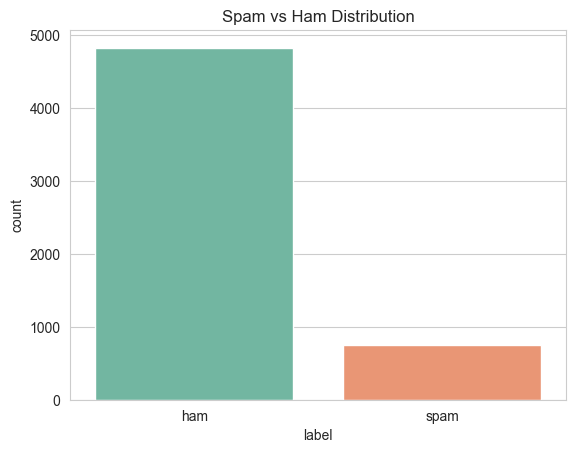

In [60]:
counts = Emai_spam['label'].value_counts()
pct = Emai_spam['label'].value_counts(normalize=True) * 100
print(counts)
print("\nPercentages:\n", pct.round(2))

sns.countplot(data=Emai_spam, x='label', palette='Set2')
plt.title('Spam vs Ham Distribution')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 4\spam_ham_distribution.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Observation:** The dataset is imbalanced — roughly 87% ham vs 13% spam, which is typical of real-world spam data and is one reason accuracy alone can be misleading.

## Text Preprocessing

In [61]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

Emai_spam['clean_text'] = Emai_spam['text'].apply(clean_text)
Emai_spam[['text', 'clean_text']].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


**Preprocessing steps applied:** lowercasing, punctuation/number removal, and stopword removal. Stemming/lemmatization was skipped here to keep words recognizable for the word clouds below, but could be added via NLTK's `PorterStemmer` for further dimensionality reduction.

## Feature Extraction with TF-IDF

**What TF-IDF measures:** Term Frequency-Inverse Document Frequency scores each word by how often it appears in a message (Term Frequency) weighted down by how common that word is across *all* messages (Inverse Document Frequency). Words that appear frequently in a specific message but rarely elsewhere (e.g., "free", "winner", "claim") get high TF-IDF scores and are more informative for distinguishing spam, while common words appearing everywhere (even after stopword removal) get suppressed.

In [62]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(Emai_spam['clean_text'])
y = Emai_spam['label'].map({'ham': 0, 'spam': 1})

feature_summary = pd.DataFrame({
    "Metric": ["Number of Emails", "Number of TF-IDF Features"],
    "Value": [X.shape[0], X.shape[1]]
})

feature_summary

,Metric,Value
0,Number of Emails,5572
1,Number of TF-IDF Features,3000


## Train/Test Split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Columns": [X_train.shape[1], X_test.shape[1]]
})

split_summary

,Dataset,Rows,Columns
0,Training,4457,3000
1,Testing,1115,3000


## Train Classifiers

In [64]:
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Predictions": preds,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results).drop(columns="Predictions").round(3)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.977,0.992,0.832,0.905
1,Logistic Regression,0.969,0.991,0.772,0.868


## Evaluation

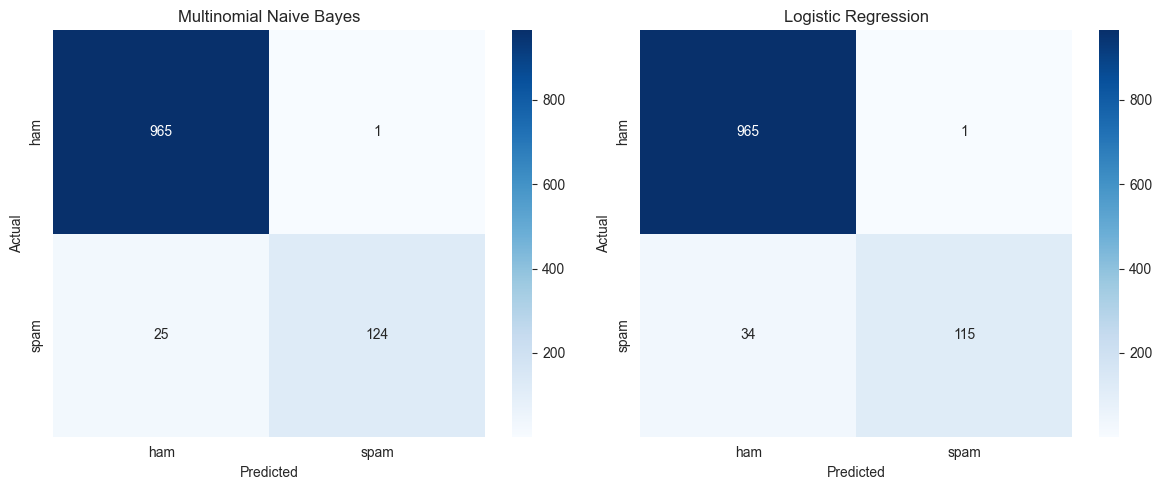

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res in zip(axes, results):

    cm = confusion_matrix(y_test, res["Predictions"])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["ham", "spam"],
        yticklabels=["ham", "spam"]
    )

    ax.set_title(res["Model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 4\spam_ham_Evaluation.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

In [66]:
for res in results:

    report = classification_report(
        y_test,
        res["Predictions"],
        target_names=["ham", "spam"],
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose().round(3)

    display(res["Model"])
    display(report_df)

'Multinomial Naive Bayes'

,precision,recall,f1-score,support
ham,0.975,0.999,0.987,966.000
spam,0.992,0.832,0.905,149.000
accuracy,0.977,0.977,0.977,0.977
macro avg,0.983,0.916,0.946,1115.000
weighted avg,0.977,0.977,0.976,1115.000


'Logistic Regression'

,precision,recall,f1-score,support
ham,0.966,0.999,0.982,966.000
spam,0.991,0.772,0.868,149.000
accuracy,0.969,0.969,0.969,0.969
macro avg,0.979,0.885,0.925,1115.000
weighted avg,0.969,0.969,0.967,1115.000


## Why Recall Matters for Spam Detection

Recall measures the proportion of *actual* spam messages the model successfully catches. In spam detection, a **false negative** (spam that slips into the inbox as "ham") is generally more tolerable than a **false positive** (a legitimate, possibly important, email wrongly flagged as spam and hidden from the user). However, low recall means a large share of spam consistently reaches the user, defeating the purpose of the filter. In practice, both precision and recall matter, but recall is emphasized because missing spam undermines user trust in the filter, while occasional false positives can be mitigated by a "review spam folder" habit. Many production systems tune thresholds to push recall up as long as precision stays acceptable.

## WordCloud Visualisations

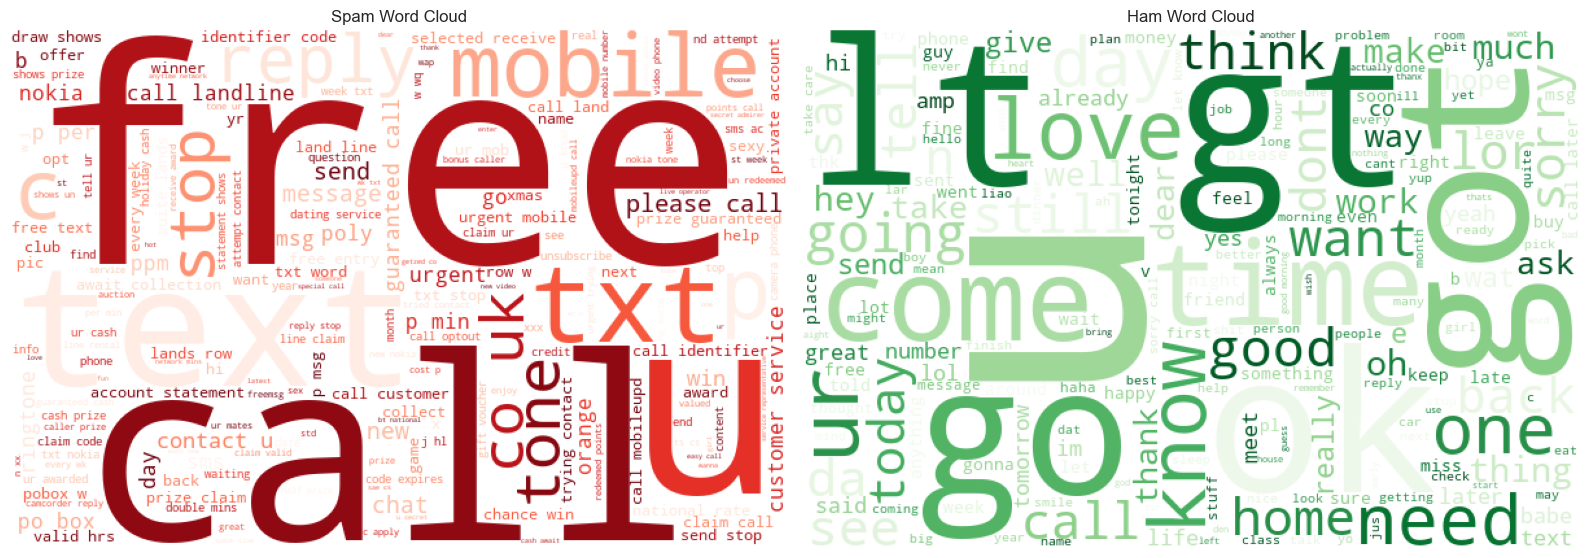

In [67]:
from wordcloud import WordCloud

spam_text = ' '.join(Emai_spam[Emai_spam['label'] == 'spam']['clean_text'])
ham_text = ' '.join(Emai_spam[Emai_spam['label'] == 'ham']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(spam_text)
axes[0].imshow(WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(spam_text))
axes[0].set_title('Spam Word Cloud')
axes[0].axis('off')

axes[1].imshow(WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(ham_text))
axes[1].set_title('Ham Word Cloud')
axes[1].axis('off')
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 4\spam_ham_wordcloud.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Conclusion:** Both Multinomial Naive Bayes and Logistic Regression perform strongly on this TF-IDF representation. Naive Bayes is the traditional baseline for text classification due to its speed and strong performance on sparse, high-dimensional TF-IDF features, while Logistic Regression often edges out slightly on precision/recall balance. The word clouds confirm the model's learned signal makes sense: spam messages are dominated by promotional/urgency words (e.g., free, win, claim, call, txt), while ham messages reflect everyday conversational language.